# Simulation Demo
This notebook is meant to be run after build_delivery.ipynb, so go take a look at that one if you haven't already. The products made there
are used in this demonstration.

In [1]:
from demosat_seq.seqcollection import SeqCollection
from demosat_seq.simulation import DemoSatSimulation
from demosat_seq.seqdict import DemoSatSeqDict
import demosat_dict
from pathlib import Path
from glob import glob
from datetime import datetime
from tts_utilities.jnb_util import this_notebook_path 

# Simulation Setup
Most of the work of creating the simulation has already been done in planning and sequencing. This cell is mostly about collecting all of the outputs and putting them in their right place for the simulation to grab them

In [2]:
dict_pkg_dir = Path(demosat_dict.__file__).parent
initial_conditions = {}
dictionary_set_path = dict_pkg_dir.joinpath('dictionaries/v1/')
sequences = SeqCollection(
    '2024_02_02 DemoSat Sequence Collection',
    [DemoSatSeqDict(s, {'command_dictionary_path': dictionary_set_path.joinpath('command.xml'), 'config_dir': ''}) for s in glob('seq_db/2024_02_02/approved/*')],
    True,
    dictionary_set_path.joinpath('command.xml')
)
sim = DemoSatSimulation(sequences, initial_conditions, dictionary_set_path)

# Simulation Exectution
All the sim needs to know to start is which sequence is at the top of the heirarchy and what time to start. It will step through a uniform step length (here configured to 1s) simulating all commands in the sequence (including any commands in sequences that are spawned from it) until there are no more commands left to model.

In the future, we plan to augment this to be able to understand initial conditions, loading and starting a new sequence by command (e.g. load-and-go), be able to daisy chain from the currently running sequence, and using actual spacecraft data as the initial condition.

In [3]:
sim.execute('background_2024_02_02', '2024-033T00:00:00')

# Exploring the Simulation Outputs
There are several useful data products that are created from this simulation. We will explore some of them here and also show an example of integrating them into an updateable plotly widget.

## Command History Container
This containter shows every command that was passed to the simulation's command module, including its arguments. Only the first few lines are shown here.

In [4]:
sim.cmd_history_container[:10]

+---------------------+---------------------------------------+--------------------+-----------------+
| time                | sequence                              | stem               | arguments       |
+=====================+=======================================+====================+=================+
| 2024-02-02 00:00:00 | background_2024_02_02                 | DO_SCIENCE         | N_HEMI,DAY      |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:07:59 | background_2024_02_02                 | STOP_SCIENCE       |                 |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:08:00 | background_2024_02_02                 | RUN_SEQ            | MCO_Sband_setup |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:08:01 | background_2024_02_02/MCO_Sband_setup | TX_POWER           | ON,XBAND        |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:08:06 | background_2024_02_02/MCO_Sband_setup | CLOSE_SCI_PRODUCTS |                 |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:08:11 | background_2024_02_02/MCO_Sband_setup | FLUSH_DL_BUFFERS   |                 |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:08:12 | background_2024_02_02/MCO_Sband_setup | SET_VCDU           | 17              |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:08:13 | background_2024_02_02/MCO_Sband_setup | SET_TLM_PROD_RATE  | XBAND_DL        |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:08:14 | background_2024_02_02/MCO_Sband_setup | SET_PLAYBACK_RATE  | 200_MBPS        |
+---------------------+---------------------------------------+--------------------+-----------------+
| 2024-02-02 00:08:15 | background_2024_02_02/MCO_Sband_setup | START_PLAYBACK     |                 |
+---------------------+---------------------------------------+--------------------+-----------------+

# EVR Container
There's also a DataContainer with all of your simulated EVRs 

In [5]:
sim.evr_container[:10]
sim.evr_container.to_csv('simulated_evrs.csv')

# EVR Container
And one with all your simulated EHA

In [6]:
sim.eha_container[:10]

2026-025T15:32:55 INFO     2026-025T15:32:55 (INFO) tts_seq.core.simulation.eha_container:        ]8;id=233434;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_seq/src/tts_seq/core/simulation.py\simulation.py]8;;\:]8;id=228522;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_seq/src/tts_seq/core/simulation.py#203\203]8;;\
                           Converting raw chanval records at 63824 times to raw records for                        
                           EhaContainer                                                                            

2026-025T15:32:56 INFO     2026-025T15:32:56 (INFO) tts_seq.core.simulation.eha_container:        ]8;id=126275;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_seq/src/tts_seq/core/simulation.py\simulation.py]8;;\:]8;id=243009;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_seq/src/tts_seq/core/simulation.py#264\264]8;;\
                           Converting 63824 raw chanval records to EhaContainer                                    

                  INFO     2026-025T15:32:56 (INFO) tts_seq.core.simulation.eha_container:        ]8;id=540465;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_seq/src/tts_seq/core/simulation.py\simulation.py]8;;\:]8;id=108290;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_seq/src/tts_seq/core/simulation.py#267\267]8;;\
                           Converted 63824 raw chanval records to EhaContainer                                     

+--------------+-------------+---------------+-------------+---------+--------+----------------+----------+--------------------------+--------------------------+-------+-------+-------------+------+---------+------+----------+----------------+----------------+------------+--------+
| recordType   |   sessionId | sessionHost   | channelId   |   dssId |   vcid | name           | module   | ert                      | scet                     | rct   | lst   |        sclk |   dn | dnStr   |   eu | status   | dnAlarmState   | euAlarmState   | realtime   | type   |
+==============+=============+===============+=============+=========+========+================+==========+==========================+==========================+=======+=======+=============+======+=========+======+==========+================+================+============+========+
| eha          |           0 | SIM           | ADCS-0001   |       0 |      0 | YAW_ANGLE      | adcs     | 2024-033T00:00:00.000000 | 2024-033T00:00:00.000000 |       |       | 7.60147e+08 |    0 |         |    0 |          | None           | None           | False      | ???    |
+--------------+-------------+---------------+-------------+---------+--------+----------------+----------+--------------------------+--------------------------+-------+-------+-------------+------+---------+------+----------+----------------+----------------+------------+--------+
| eha          |           0 | SIM           | TEL-0001    |       0 |      0 | TX_POWER_STATE | tel      | 2024-033T00:00:00.000000 | 2024-033T00:00:00.000000 |       |       | 7.60147e+08 |   -1 |         |      | OFF      | None           | None           | False      | ???    |
+--------------+-------------+---------------+-------------+---------+--------+----------------+----------+--------------------------+--------------------------+-------+-------+-------------+------+---------+------+----------+----------------+----------------+------------+--------+
| eha          |           0 | SIM           | TEL-0003    |       0 |      0 | VCDU_NO        | tel      | 2024-033T00:00:00.000000 | 2024-033T00:00:00.000000 |       |       | 7.60147e+08 |   -1 |         |      | VC0      | None           | None           | False      | ???    |
+--------------+-------------+---------------+-------------+---------+--------+----------------+----------+--------------------------+--------------------------+-------+-------+-------------+------+---------+------+----------+----------------+----------------+------------+--------+
| eha          |           0 | SIM           | MODE-0001   |       0 |      0 | SC_MODE        | tel      | 2024-033T00:00:00.000000 | 2024-033T00:00:00.000000 |       |       | 7.60147e+08 |   -1 |         |      | NOMINAL  | None           | None           | False      | ???    |
+--------------+-------------+---------------+-------------+---------+--------+----------------+----------+--------------------------+--------------------------+-------+-------+-------------+------+---------+------+----------+----------------+----------------+------------+--------+
| eha          |           0 | SIM           | ADCS-0001   |       0 |      0 | YAW_ANGLE      | adcs     | 2024-033T00:05:00.000000 | 2024-033T00:05:00.000000 |       |       | 7.60148e+08 |    0 |         |    0 |          | None           | None           | False      | ???    |
+--------------+-------------+---------------+-------------+---------+--------+----------------+----------+--------------------------+--------------------------+-------+-------+-------------+------+---------+------+----------+----------------+----------------+------------+--------+
| eha          |           0 | SIM           | TEL-0001    |       0 |      0 | TX_POWER_STATE | tel      | 2024-033T00:05:00.000000 | 2024-033T00:05:00.000000 |       |       | 7.60148e+08 |   -1 |         |      | OFF      | None           | None           | False      | ???    |
+--------------+-------------+--------

## Plots

The Simulation also models time-series data. Two plots are shown as a demonstration, but anything that is simulated can be plotted in this way.

The argument for sim.plot() is passed directly to dtat, so you can use the same conventions to put channels on the same plot or grouped together as subplots.

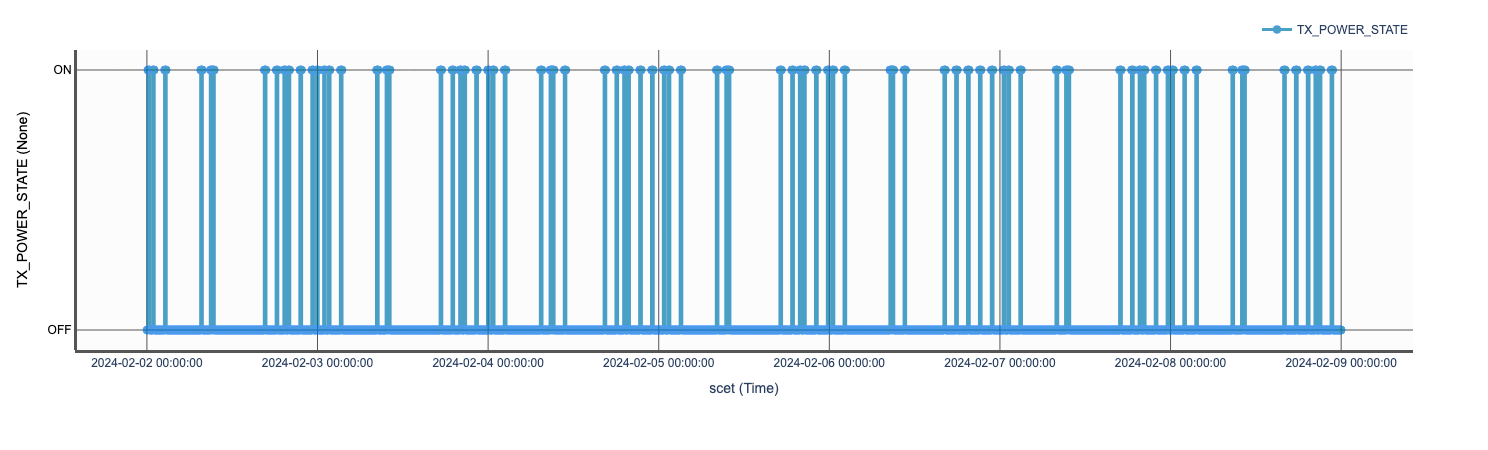

In [7]:
sim.plot([['TX_POWER_STATE']])

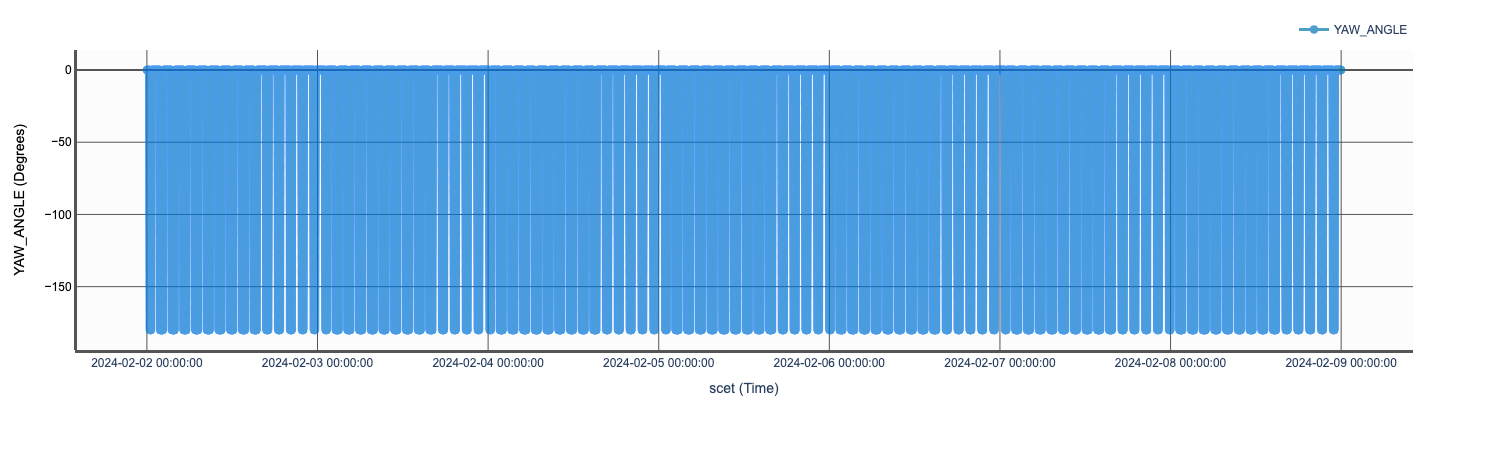

In [8]:
sim.plot([['YAW_ANGLE']])

# Integrated Dashboard
This shows an example of an integrated dashboard that is built around an orbit track widget in the EarthMap class. It uses html_utils's IPythonGrid class to generate a flexbox and sync tables with the position of the spacecraft on the map

* **Ground Track**: Shows the track that the spacecraft is moving into and where it has come from. For 50 minutes in each direction. Also shows the subsolar point and the positions of ground stations used by the project
* **Tabe Displays**: These are populated by the `power_table` method of any data container. Data container default CSS styling is honored, and an additional row is added to show where in the list the current map display time appears. The number of records before and after the display time are configurable
* **Plots**: By passing a dtat-style list of lists of telemetry channel names, any simulated channel can be displayed here.
* **Condiguration**: the `configure_layout` method allows the developer to choose the number of rows, the number of cells per row, and their exact sizes. Upon changing the slider, all plotly widgets (e.g. the map and plots) will resize to fit their container. Widths are percentages to maximize support of different window styles, but for best support, consider making a compact, expansive, and middle ground layout that operators can choose from.

In [9]:
from tts_seq.sim_visualization.earthmap import EarthMap
from demosat_data_utils.ground_stations import GroundStationContainer
from demosat_data_utils.ephemeris import EphemerisContainer
from demosat_data_utils.orbit_events import OrbitEventContainer
ephem_container = EphemerisContainer(csv_path='ephemeris.txt', cast_fields=True)
orbit_events = OrbitEventContainer(ephem=ephem_container)

earth_map = EarthMap(epehmeris_csv_path='ephemeris.txt')
earth_map.add_plot([['YAW_ANGLE']], sim.dtat_dataframe(), name='Yaw Angle Plot')
earth_map.add_plot([['TX_POWER_STATE']], sim.dtat_dataframe(), name='TX Power Plot')
earth_map.add_table(sim.cmd_history_container, 'time', 3, 5, name='Command History')
earth_map.add_table(orbit_events, 'Time', 3, 5, name='Orbit Events')
earth_map.add_table(sim.evr_container, 'scet', 3, 5, name='Simulated EVRs')
earth_map.configure_layout([
    [['controls', '140px', '100%']],
    [['map', '400px', '33%'], ['Command History', '400px', '34%'], ['Orbit Events', '400px', '33%']],
    [['Yaw Angle Plot', '425px', '50%'],['TX Power Plot', '425px', '50%']],
    [['Simulated EVRs', '400px', '100%']]
])

earth_map.display()

2026-025T15:32:58 INFO     2026-025T15:32:58 (INFO) tts_spice.furnish.furnish_kernel: Loaded SPICE   ]8;id=51637;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py\furnish.py]8;;\:]8;id=684528;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py#158\158]8;;\
                           kernel:                                                                                 
                           /Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/k               
                           ernels/naif0012.tls                                                                     

                  INFO     2026-025T15:32:58 (INFO) tts_spice.furnish.furnish_kernel: Loaded SPICE   ]8;id=572611;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py\furnish.py]8;;\:]8;id=270797;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py#158\158]8;;\
                           kernel:                                                                                 
                           /Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/k               
                           ernels/de430.bsp                                                                        

                  INFO     2026-025T15:32:58 (INFO) tts_spice.furnish.furnish_kernel: Loaded SPICE   ]8;id=206588;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py\furnish.py]8;;\:]8;id=66845;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py#158\158]8;;\
                           kernel:                                                                                 
                           /Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/k               
                           ernels/pck00010.tpc                                                                     

                  INFO     2026-025T15:32:58 (INFO) tts_spice.furnish.furnish_kernel: Loaded SPICE   ]8;id=897601;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py\furnish.py]8;;\:]8;id=836528;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py#158\158]8;;\
                           kernel:                                                                                 
                           /Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/k               
                           ernels/earth_latest_high_prec.bpc                                                       

# Writing outputs
For the purposes of the larger integrated demo, we write out EVRs, EHA, and Command history to CSV. We can use their respective data containers to read them into Tower, our analysis tool. In a real mission this may be done with simple file writes like we do here, or these products could be saved to a telemetry database.

In [10]:
this_notebook_path().parent.joinpath('sim_outputs').mkdir(exist_ok=True)
sim.evr_container.to_csv('sim_outputs/simulated_evrs.csv')
sim.eha_container.to_csv('sim_outputs/simulated_eha.csv')
sim.cmd_history_container.to_csv('sim_outputs/simulated_cmd_history.csv')